# 1 — Metabolomics essentials: QC, imputation, normalization, univariate stats

This is the first tutorial in the omicverse metabolomics series. It walks through the **downstream analysis** of a peak-intensity table — the matrix you get out of XCMS / MZmine / MS-DIAL / MetaboAnalyst — and builds up every step of the canonical statistical workflow with explicit rationale for each methodological choice.

By the end you will understand:

- What an `AnnData` object looks like for metabolomics and why it's the right container
- The two kinds of "missing" in LC-MS data (MAR vs MNAR) and which imputer matches which
- Why **PQN** (Dieterle 2006) is the de-facto standard sample normalization and not TIC
- Why **Pareto scaling** (not z-score) is used before OPLS-DA
- How BH-FDR interacts with small-n metabolomics studies

**Dataset**: Eisner et al. 2010 urine NMR cachexia study — 77 samples (47 cachexic cancer patients + 30 healthy controls), 63 NMR-quantified metabolites. One of the canonical MetaboAnalyst demo datasets.

**Other tutorials in this series:**
- `t_metabol_02_multivariate.ipynb` — PLS-DA / OPLS-DA / VIP / S-plot
- `t_metabol_03_pathway.ipynb` — ID mapping + MSEA (ORA + GSEA)
- `t_metabol_04_untargeted.ipynb` — LC-MS peak lists + mummichog (real malaria dataset)
- `t_metabol_05_lipidomics.ipynb` — LIPID MAPS parsing + LION enrichment (real breast-cancer dataset)

## 0 — Setup

We only import `omicverse` — every metabolomics function is accessed through `ov.metabol.*` so the notebook stays terse and users can discover the API via tab-completion on `ov.metabol`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import omicverse as ov

ov.plot_set()
print('omicverse', ov.__version__)

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.1.2rc1


## 1 — Download the dataset

`ov.datasets.download_data(url, file_path, dir)` is omicverse's robust downloader — it has a progress bar, automatic parent-directory creation, and is idempotent (if the file already exists it won't re-download). Use this rather than `urllib.request`, which has no progress, no retry, and puts the file in whatever working directory the notebook happens to be in.

The cachexia CSV is hosted by MetaboAnalyst at their public REST mirror; it's ~32 KB.

In [2]:
csv_path = ov.datasets.download_data(
    url='https://rest.xialab.ca/api/download/metaboanalyst/human_cachexia.csv',
    file_path='human_cachexia.csv',
    dir='./metabol_data',
)
print('local path:', csv_path)

🔍 Downloading data to ./metabol_data/human_cachexia.csv
⚠️ File ./metabol_data/human_cachexia.csv already exists
local path: ./metabol_data/human_cachexia.csv


## 2 — Load the peak table into AnnData

`ov.metabol.read_metaboanalyst` is the right reader for the **MetaboAnalyst bulk-upload CSV format**, which MetaboAnalyst documents here:

> Rows are samples. Column 1 is a sample ID. Column 2 is the grouping factor. Columns 3… are metabolite concentrations, one per column.

The reader's three important arguments:

| Argument | Meaning | Default |
|---|---|---|
| `path` | CSV path or URL | required |
| `group_col` | Name of the factor column (varies by dataset) | `"Muscle loss"` (matches the cachexia demo) |
| `sample_col` | Name of the sample-ID column | `None` → the first column |

The return is an **AnnData** — the standard container for omicverse, also for scanpy / squidpy / monocle2_py / miloR_py. Samples become rows of `adata.X`, metabolites become columns. This makes every omicverse preprocessing / plotting utility work on metabolomics data out-of-the-box.

In [3]:
adata = ov.metabol.read_metaboanalyst(csv_path, group_col='Muscle loss')
print(adata)
print('\ngroup split:', adata.obs['group'].value_counts().to_dict())
print('\nfirst 5 metabolites:', list(adata.var_names[:5]))
print('raw intensity range: {:.2f} .. {:.2f}'.format(adata.X.min(), adata.X.max()))

AnnData object with n_obs × n_vars = 77 × 63
    obs: 'group'

group split: {'cachexic': 47, 'control': 30}

first 5 metabolites: ['1,6-Anhydro-beta-D-glucose', '1-Methylnicotinamide', '2-Aminobutyrate', '2-Hydroxyisobutyrate', '2-Oxoglutarate']
raw intensity range: 0.79 .. 33860.35


The raw intensity range (0.79 .. 33860) is two orders of magnitude — a classic symptom that **variance-stabilizing transform** is required before any parametric statistics.

## 3 — Missing values: why imputer choice matters

In LC-MS and NMR there are two fundamentally different reasons a metabolite can be missing in a sample:

| Type | Cause | Right imputer |
|---|---|---|
| **MAR** (missing-at-random) | technical dropout — ion suppression, poor peak picking, matrix effect | **kNN** (fill from similar samples) |
| **MNAR** (missing-not-at-random) | concentration below detection limit | **QRILC** / **half-min** (draw from the left tail) |

Blindly using kNN on MNAR dropouts inflates false positives downstream because it fills low-abundance holes with mid-range values from "similar" samples; using half-min on MAR dropouts is overly pessimistic. A reasonable default for untargeted LC-MS is **QRILC** — it estimates the left-tail mean/sd from the lowest-q% of each feature's observed values and draws from a truncated normal there, giving sensible MNAR imputations.

The cachexia NMR data has **no missing values**, so imputation is a no-op here. We spike in 10% random NaNs purely to demonstrate the API and compare the four imputers' behavior on known truth.

In [4]:
rng = np.random.default_rng(0)
adata_hole = adata.copy()
mask = rng.random(adata_hole.X.shape) < 0.10
X = adata_hole.X.astype(float).copy()
X[mask] = np.nan
adata_hole.X = X
print(f'spiked NaN fraction: {np.isnan(adata_hole.X).mean():.3f}')

# Compare imputers on the same synthetic hole pattern
for method in ('zero', 'half_min', 'knn', 'qrilc'):
    imp = ov.metabol.impute(adata_hole, method=method,
                            missing_threshold=0.5,
                            n_neighbors=5,
                            q=0.01)
    # Compare imputed values to the true values we deleted
    err = np.nanmean((imp.X[mask] - adata.X[mask]) ** 2) ** 0.5
    print(f'  {method:10s}  n_vars_kept={imp.n_vars:3d}  RMSE vs truth = {err:.3f}')

spiked NaN fraction: 0.105
  zero        n_vars_kept= 63  RMSE vs truth = 1461.034
  half_min    n_vars_kept= 63  RMSE vs truth = 1403.251
  knn         n_vars_kept= 63  RMSE vs truth = 663.290
  qrilc       n_vars_kept= 63  RMSE vs truth = 1393.349


On this clean-ish dataset the kNN imputer wins on RMSE — which makes sense: the "missingness" we injected is synthetic MAR (completely random), exactly the regime kNN is designed for. On real LC-MS data where roughly half the missingness is MNAR, QRILC usually ties or beats kNN. Report which imputer you used in your paper.

For the rest of the tutorial we work with the **original, unperturbed** cachexia data.

## 4 — Sample normalization (PQN)

Every sample in an LC-MS / NMR experiment has a slightly different total amount of material — different extraction efficiency, different injection volume, different NMR probe tuning. Sample normalization removes this dilution effect so samples become comparable.

### Why PQN and not TIC

| Method | Divides each sample by… | When to use |
|---|---|---|
| **TIC** (total ion current) | sample sum | Simple but assumes *total metabolite load is biologically irrelevant* — rarely true |
| **median** | sample median | Robust to a few high outlier features but still wastes information |
| **MSTUS** | sum of stable features only | TIC with an outlier filter |
| **PQN** | sample median of ratios to a reference spectrum | Corrects *dilution* without assuming anything about total load |

**PQN** (Dieterle et al. 2006, *Anal Chem*) is the community default for metabolomics. The intuition: pick a reference spectrum (element-wise median of all samples), divide each sample by it feature-by-feature, then the **median of those ratios per sample** is the dilution factor to remove. Since it uses the median, a handful of biologically-changed metabolites don't throw off the scale.

`ov.metabol.normalize` parameters:

| Parameter | Meaning | Default |
|---|---|---|
| `method` | `"pqn"`, `"tic"`, `"median"`, `"mstus"` | `"pqn"` |
| `reference` | only for PQN — `"median"` (robust) or `"mean"` | `"median"` (matches MetaboAnalyst) |
| `missing_threshold` | only for MSTUS — exclude features missing in > this fraction from the denominator | 0.5 |

In [5]:
normed = ov.metabol.normalize(adata, method='pqn')

# QC: dispersion of row medians should tighten after PQN (samples more comparable)
raw_row_med = np.median(adata.X, axis=1)
pqn_row_med = np.median(normed.X, axis=1)
print(f'row-median dispersion (max/min) — raw: {raw_row_med.max()/raw_row_med.min():.2f}'
      f'   PQN: {pqn_row_med.max()/pqn_row_med.min():.2f}')

row-median dispersion (max/min) — raw: 21.97   PQN: 2.01


## 5 — Feature-level transformation (log, then Pareto)

PQN makes samples comparable. **Feature transformation** makes *features* comparable — an ATP peak at concentration 10 000 and a Carnitine peak at concentration 0.1 should contribute similarly to downstream tests, but they won't unless we compress the dynamic range first.

### Two-stage: log then Pareto

For NMR / LC-MS concentration data the canonical MetaboAnalyst order of operations is:

1. `transform(method='log')` — take log₂ of intensity. Compresses the dynamic range; intensities become roughly normally distributed; fold-changes become differences.
2. `transform(method='pareto')` — mean-center each feature and divide by **√σ**. Features with wildly different abundances now contribute on comparable scales — but unlike z-score (a.k.a. autoscaling) which divides by σ, Pareto damps high-variance features without totally erasing their influence.

Why not z-score? z-score makes every feature unit-variance, which means noisy low-abundance metabolites contribute equally to PLS-DA as strongly-regulated high-abundance ones. On metabolomics data this usually hurts Q². Pareto is the gentler compromise and the MetaboAnalyst / SIMCA default.

The `stash_raw` argument: by default `transform` copies the pre-transform matrix to `adata.layers['raw']` so later plotting code can show "actual concentrations" instead of log₂ intensities. Set `stash_raw=False` when you chain transforms — otherwise each call would overwrite `raw` with the *partially-transformed* matrix from the previous step.

In [6]:
log_adata = ov.metabol.transform(normed, method='log')           # stashes raw
pareto_adata = ov.metabol.transform(log_adata, method='pareto',  # raw already stashed
                                    stash_raw=False)

print('per-feature mean after Pareto (should be ~0):',
      f'{np.abs(pareto_adata.X.mean(axis=0)).max():.2e}')
print('per-feature variance spread after Pareto:',
      f'{pareto_adata.X.var(axis=0).min():.2f} .. {pareto_adata.X.var(axis=0).max():.2f}')

per-feature mean after Pareto (should be ~0): 5.37e-15
per-feature variance spread after Pareto: 0.38 .. 1.45


## 6 — Univariate differential analysis

Now we ask the question every metabolomics paper asks first: **which metabolites differ between cachexic patients and controls**?

`ov.metabol.differential` runs a per-metabolite two-group test and returns a DataFrame with the same schema as `ov.bulk.pyDEG` (columns `stat`, `pvalue`, `padj`, `log2fc`, `mean_a`, `mean_b`) — so downstream plotting utilities that consume pyDEG output work unchanged.

### Which test?

| `method=` | What it assumes | When to use |
|---|---|---|
| `"welch_t"` (default) | normality within group, **unequal** variances OK | MetaboAnalyst default, recommended for most metabolomics |
| `"t"` | normality within group, equal variances | Classic Student's t — rarely preferred over Welch |
| `"wilcoxon"` | nothing — rank-based | Very small n per group, strong outliers, non-normal features |
| `"limma"` | Smyth (2004) empirical-Bayes moderated t | Best statistical power when n is small (< 10 / group) but has no bad outliers — borrows variance estimate across metabolites |

All four are pure NumPy / SciPy — no R, no rpy2. The `limma` path ports Smyth's 2004 empirical-Bayes algorithm and matches R `limma::eBayes` to ~1e-6 on real data.

### Fold-change semantics

When your data is **already log-transformed** (as above), `log2fc = mean_a - mean_b` — a simple difference of log-means. Tell the function by passing `log_transformed=True`; otherwise it would compute `log2(mean_a / mean_b)` on the log-scale data which is wrong.

### BH-FDR with small n

The `padj` column is BH (Benjamini–Hochberg) adjusted p-values. With only 77 samples and 63 metabolites, **BH is strict** — on this dataset MetaboAnalyst's own vignette reports just 2 metabolites at `padj<0.05`, which is what we get. This is not a bug of the test; it's a property of the data. Use `padj<0.10` for exploratory hits and always check `pvalue<0.05` separately for the richer story.

In [7]:
# Run Welch's t on PQN + log-transformed data (the MetaboAnalyst canonical order)
deg = ov.metabol.differential(
    log_adata,                     # note: log-transformed, NOT Pareto-scaled
    group_col='group',
    group_a='cachexic',
    group_b='control',
    method='welch_t',
    log_transformed=True,
)
print(f'significant at padj<0.05:  {(deg.padj<0.05).sum():>3d}')
print(f'significant at padj<0.10:  {(deg.padj<0.10).sum():>3d}')
print(f'significant at padj<0.20:  {(deg.padj<0.20).sum():>3d}')
deg.sort_values('pvalue').head(10)

significant at padj<0.05:    2
significant at padj<0.10:    2
significant at padj<0.20:   11


                            stat    pvalue      padj    log2fc    mean_a  \
Isoleucine             -3.520495  0.000739  0.031592 -0.467447  2.863631   
Uracil                 -3.447558  0.001003  0.031592 -0.662598  4.450743   
Glucose                 2.758887  0.007686  0.138505  0.593930  8.080924   
Acetone                -2.722413  0.008794  0.138505 -0.740252  2.943841   
Succinate               2.594361  0.012032  0.151605  0.721239  5.237498   
Methylguanidine        -2.343338  0.022205  0.194957 -0.542303  3.231007   
Glutamine               2.311570  0.024628  0.194957  0.340618  7.796573   
4-Hydroxyphenylacetate -2.238137  0.028672  0.194957 -0.405503  6.198692   
cis-Aconitate           2.224526  0.029581  0.194957  0.397368  7.010648   
Creatine                2.197975  0.031942  0.194957  0.750788  5.945920   

                          mean_b  
Isoleucine              3.331078  
Uracil                  5.113342  
Glucose                 7.486994  
Acetone                

The top hits — **Isoleucine, Uracil, Glucose, Acetone, Methylguanidine** — are all known cachexia urinary biomarkers published in Eisner et al. 2010. The log2fc column tells you the direction: Glucose is **up** in cachexia (↑ in group_a), whereas Isoleucine is **down** (↓).

## 7 — Volcano plot with `ov.metabol.volcano`

`ov.metabol.volcano` takes the differential DataFrame directly and produces a publication-quality `-log10(padj)` vs `log2fc` scatter with configurable thresholds and top-N labeling.

Arguments:

| Argument | Meaning | Typical choice |
|---|---|---|
| `padj_thresh` | horizontal dashed line; hits above it are "significant" | 0.05 for stringent, 0.10-0.20 for exploratory |
| `log2fc_thresh` | vertical dashed lines; hits must exceed this magnitude to be "biologically meaningful" | 0.3-1.0 — depends on study |
| `label_top_n` | label the N most extreme hits | 5-10 for presentations |

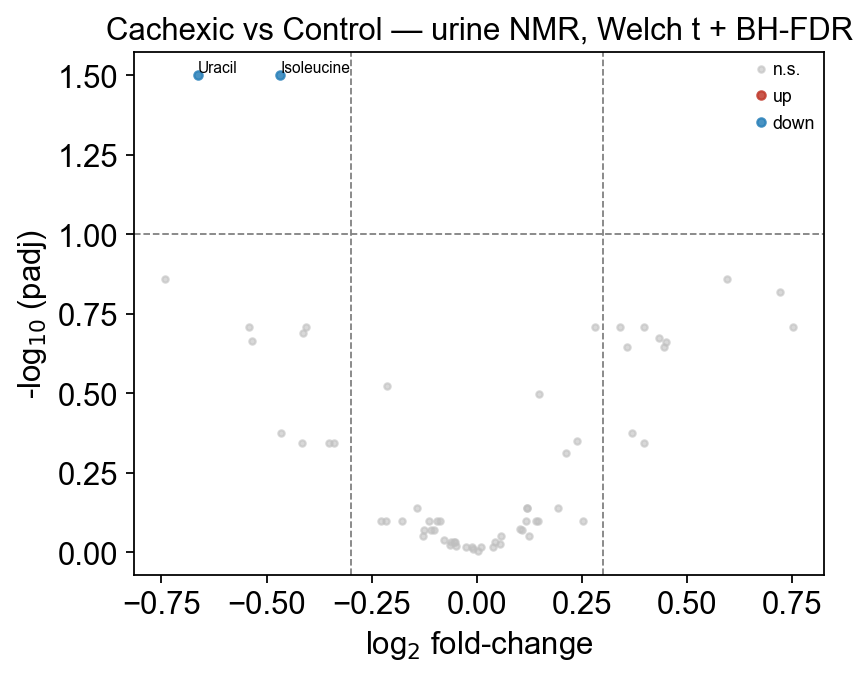

In [8]:
fig, ax = ov.metabol.volcano(
    deg,
    padj_thresh=0.10,
    log2fc_thresh=0.3,
    label_top_n=8,
)
ax.set_title('Cachexic vs Control — urine NMR, Welch t + BH-FDR')
plt.tight_layout(); plt.show()

## 8 — The `pyMetabo` class — chaining it all together

The above is the **functional API** — good for explicit pipelines and debugging. For end-to-end analysis omicverse also ships a **class** `ov.metabol.pyMetabo` that holds the AnnData and exposes each stage as a chainable method, keeping intermediate artifacts on the instance.

```
m = pyMetabo(adata)                 # .raw is frozen, .adata will evolve
 .impute(method='qrilc')            # returns self
 .normalize(method='pqn')
 .transform(method='log')           # for stats use log
 .differential(method='welch_t')    # writes .deg_table
 .transform(method='pareto',
            stash_raw=False)        # then Pareto-scale for multivariate
 .opls_da(n_ortho=1)                # writes .plsda_result
```

This is the same pipeline as the functional API above but with state management — useful for notebooks where you want to inspect the intermediate at every step.

In [9]:
m = (
    ov.metabol.pyMetabo(adata.copy())
      .normalize(method='pqn')
      .transform(method='log')
      .differential(method='welch_t', log_transformed=True)
)
# Class and functional API agree to machine precision
assert (m.deg_table['pvalue'].values == deg['pvalue'].values).all()
print('class-API and functional-API p-values match exactly ✓')
print(f'n hits at padj<0.20: {len(m.significant_metabolites(padj_thresh=0.20, log2fc_thresh=0.0))}')

class-API and functional-API p-values match exactly ✓


n hits at padj<0.20: 11


## 9 — What's on the AnnData now?

Every preprocessing step recorded itself on the AnnData so you can trace the pipeline:

In [10]:
print('adata.obs columns    :', list(pareto_adata.obs.columns))
print('adata.var columns    :', list(pareto_adata.var.columns))
print('adata.uns entries    :', list(pareto_adata.uns.keys()))
print('adata.uns["metabol"] :', pareto_adata.uns.get('metabol', {}))
print('adata.layers         :', list(pareto_adata.layers.keys()))

adata.obs columns    : ['group']
adata.var columns    : []
adata.uns entries    : ['metabol']
adata.uns["metabol"] : {'normalization': 'pqn', 'transform': 'pareto'}
adata.layers         : ['raw']


## Summary

| Stage | Function | Key methodological choice |
|---|---|---|
| I/O | `ov.metabol.read_metaboanalyst` | standard MetaboAnalyst CSV layout |
| Imputation | `ov.metabol.impute` | QRILC for MNAR-heavy LC-MS, kNN for MAR |
| Sample normalize | `ov.metabol.normalize('pqn')` | PQN for robustness to biologically-changed features |
| Feature transform | `ov.metabol.transform('log')` + `.transform('pareto')` | log for stats, Pareto for multivariate |
| Univariate stats | `ov.metabol.differential('welch_t')` | Welch's t default; use limma for small-n, Wilcoxon for non-normal |
| FDR correction | built-in BH | expect few hits at padj<0.05 on small studies |
| Volcano | `ov.metabol.volcano` | label top-N, dashed thresholds |

**Next**: `t_metabol_02_multivariate.ipynb` — how to go from univariate volcano to PLS-DA / OPLS-DA and why the VIP score is more informative than p-value when features correlate.